# PART 11

Haikal Ali_1103223071_TK46GAB

# Chapter 11 — General Linear Models dan Least Squares

Notebook ini dibuat dari materi **Chapter 11: General Linear Models and Least Squares**.  
Bagian teori ditulis sebagai markdown. Bagian yang memiliki kode atau exercise dibuat sebagai code cell.

## General Linear Models

General Linear Model (GLM) adalah model statistik yang menghubungkan variabel prediktor atau variabel independen dengan variabel observasi atau variabel dependen.

Dalam notasi aljabar linear, bentuk umum persamaan adalah:

$$Ax=b$$

Dalam statistik, bentuk yang sama ditulis sebagai:

$$X\beta=y$$

Keterangan istilah:

| Aljabar Linear | Statistik | Keterangan |
|---|---|---|
| $A$ | $X$ | Design matrix, berisi prediktor/regressor |
| $x$ | $\beta$ | Koefisien regresi atau parameter beta |
| $b$ | $y$ | Variabel dependen atau data observasi |

## Menyusun General Linear Model

Contoh model pada materi:

$$y = \beta_0 + \beta_1w + \beta_2h + \epsilon$$

Keterangan:

- $y$ adalah tinggi individu.
- $w$ adalah berat individu.
- $h$ adalah tinggi orang tua.
- $\epsilon$ adalah error atau residual.
- $\beta$ adalah koefisien yang dicari dari data.

Contoh data pada materi:

| y | w | h |
|---|---|---|
| 175 | 70 | 177 |
| 181 | 86 | 190 |
| 159 | 63 | 180 |
| 165 | 62 | 172 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from scipy.linalg import solve_triangular

np.set_printoptions(precision=3, suppress=True)

In [2]:
# Data contoh tinggi badan dari materi
y_height = np.array([175, 181, 159, 165])

w = np.array([70, 86, 63, 62])
h = np.array([177, 190, 180, 172])

# Design matrix: intercept, berat, tinggi orang tua
X_height = np.column_stack((np.ones(len(y_height)), w, h))

print("Design matrix X:")
print(X_height)

print("\nVector y:")
print(y_height)

Design matrix X:
[[  1.  70. 177.]
 [  1.  86. 190.]
 [  1.  63. 180.]
 [  1.  62. 172.]]

Vector y:
[175 181 159 165]


## Least Squares

Solusi GLM dicari dengan left-inverse dari design matrix:

$$\beta = (X^TX)^{-1}X^Ty$$

Persamaan ini disebut **least squares solution**. Tujuannya adalah mencari kombinasi linear kolom-kolom pada $X$ yang paling dekat dengan data observasi $y$.

In [3]:
# Least squares solution
X_leftinv = np.linalg.inv(X_height.T @ X_height) @ X_height.T
beta_height = X_leftinv @ y_height

print("Beta:")
print(beta_height)

yhat_height = X_height @ beta_height
residual_height = yhat_height - y_height

print("\nPrediksi:")
print(yhat_height)

print("\nResidual:")
print(residual_height)

Beta:
[276.856   1.517  -1.187]

Prediksi:
[172.886 181.717 158.708 166.689]

Residual:
[-2.114  0.717 -0.292  1.689]


## Apakah Solusinya Selalu Eksak?

Persamaan $X\beta=y$ hanya dapat diselesaikan secara eksak jika $y$ berada di column space dari $X$.

Pada data nyata, $y$ hampir tidak pernah tepat berada di column space dari $X$, karena data memiliki noise dan model biasanya hanya penyederhanaan dari kondisi dunia nyata.

Karena itu GLM sering ditulis dengan residual:

$$\epsilon = X\beta - y$$

## Perspektif Geometris Least Squares

Secara geometris, least squares mencari titik di column space dari $X$ yang paling dekat dengan vektor data $y$.

Residual atau error harus tegak lurus terhadap column space dari $X$:

$$X^T\epsilon = 0$$

Dari hubungan ini, solusi least squares dapat diturunkan kembali:

$$X^T(y-X\beta)=0$$

$$X^TX\beta=X^Ty$$

$$\beta=(X^TX)^{-1}X^Ty$$

## Mengapa Disebut Least Squares?

Least squares meminimalkan jumlah kuadrat error antara data prediksi dan data observasi.

Residual:

$$\epsilon = X\beta-y$$

Objektif minimisasi:

$$\min_\beta \|X\beta-y\|^2$$

## Contoh GLM Sederhana

Contoh pada materi memakai data survei fiktif tentang jumlah kursus yang diambil dan tingkat kebahagiaan hidup.

Model tanpa intercept berbentuk:

$$y=mx$$

Model dengan intercept berbentuk:

$$y=mx+b$$

Intercept membuat garis fit tidak dipaksa melewati titik origin.

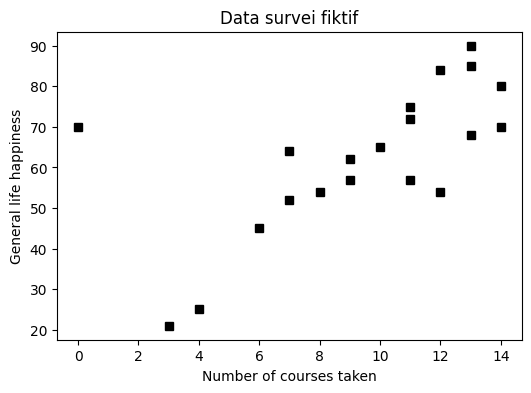

In [4]:
# Data latihan untuk contoh GLM sederhana.
# Nilai pertama dan terakhir pada happiness dibuat 70 agar sesuai dengan instruksi exercise outlier.
numcourses = np.array([0, 4, 12, 3, 14, 13, 12, 9, 11, 7,
                       13, 11, 9, 13, 11, 10, 8, 7, 6, 14])

happiness = np.array([70, 25, 54, 21, 80, 68, 84, 62, 57, 64,
                      85, 75, 57, 90, 72, 65, 54, 52, 45, 70])

plt.figure(figsize=(6,4))
plt.plot(numcourses, happiness, 'ks')
plt.xlabel("Number of courses taken")
plt.ylabel("General life happiness")
plt.title("Data survei fiktif")
plt.show()

In [5]:
# Model tanpa intercept
X_no_intercept = np.array(numcourses, ndmin=2).T
beta_no_intercept = np.linalg.inv(X_no_intercept.T @ X_no_intercept) @ X_no_intercept.T @ happiness
pred_no_intercept = X_no_intercept @ beta_no_intercept
sse_no_intercept = np.sum((pred_no_intercept - happiness)**2)

print("Beta tanpa intercept:")
print(beta_no_intercept)
print("SSE tanpa intercept:", sse_no_intercept)

Beta tanpa intercept:
[6.171]
SSE tanpa intercept: 6820.830958230958


Beta dengan intercept:
[34.129  3.034]
SSE dengan intercept: 3540.6114116210083


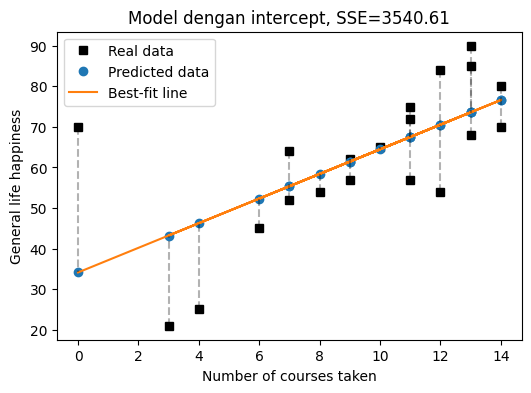

In [6]:
# Model dengan intercept
X = np.column_stack((np.ones(len(numcourses)), numcourses))

beta = np.linalg.inv(X.T @ X) @ X.T @ happiness
pred = X @ beta
resid = pred - happiness
sse = np.sum(resid**2)

print("Beta dengan intercept:")
print(beta)
print("SSE dengan intercept:", sse)

plt.figure(figsize=(6,4))
plt.plot(numcourses, happiness, 'ks', label="Real data")
plt.plot(numcourses, pred, 'o', label="Predicted data")
plt.plot(numcourses, pred, '-', label="Best-fit line")

for xi, yi, pi in zip(numcourses, happiness, pred):
  plt.plot([xi, xi], [yi, pi], 'k--', alpha=.3)

plt.xlabel("Number of courses taken")
plt.ylabel("General life happiness")
plt.title(f"Model dengan intercept, SSE={sse:.2f}")
plt.legend()
plt.show()

## Least Squares via QR

Solusi least squares juga dapat dihitung memakai QR decomposition.

Dimulai dari:

$$X\beta=y$$

Karena $X=QR$, maka:

$$QR\beta=y$$

Premultiply dengan $Q^T$:

$$R\beta=Q^Ty$$

Sehingga:

$$\beta=R^{-1}Q^Ty$$

Metode QR lebih stabil secara numerik dibanding menghitung left-inverse secara eksplisit.

In [7]:
# Least squares via QR
Q, R = np.linalg.qr(X)

beta_qr = np.linalg.inv(R) @ Q.T @ happiness

print("Beta dari left-inverse:")
print(beta)

print("\nBeta dari QR:")
print(beta_qr)

Beta dari left-inverse:
[34.129  3.034]

Beta dari QR:
[34.129  3.034]


# Code Exercises

## Exercise 11-1

Residual harus orthogonal terhadap data prediksi model.  
Tunjukkan dengan scatterplot antara predicted data dan error, lalu hitung dot product dan correlation coefficient.

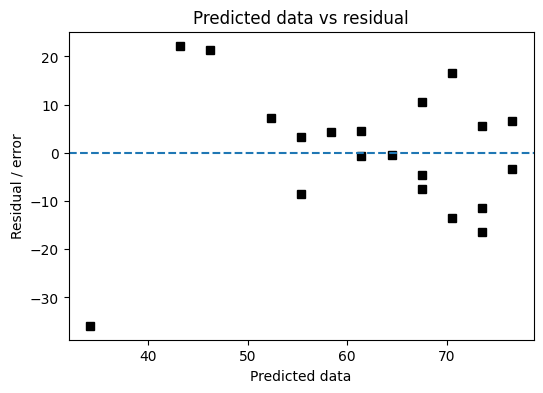

Dot product antara predicted data dan residual:
-6.269829100347124e-11

Correlation coefficient antara predicted data dan residual:
-3.164233136603857e-16

Keduanya mendekati nol karena residual orthogonal terhadap model-predicted data.


In [8]:
# Exercise 11-1
eps = pred - happiness

plt.figure(figsize=(6,4))
plt.plot(pred, eps, 'ks')
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted data")
plt.ylabel("Residual / error")
plt.title("Predicted data vs residual")
plt.show()

dot_pred_eps = np.dot(pred, eps)
corr_pred_eps = np.corrcoef(pred, eps)[0,1]

print("Dot product antara predicted data dan residual:")
print(dot_pred_eps)

print("\nCorrelation coefficient antara predicted data dan residual:")
print(corr_pred_eps)

print("\nKeduanya mendekati nol karena residual orthogonal terhadap model-predicted data.")

## Exercise 11-2

Residual tidak hanya orthogonal terhadap satu kombinasi linear dari design matrix, tetapi terhadap seluruh subspace yang dibentuk oleh design matrix.

In [9]:
# Exercise 11-2
orthogonality_check = X.T @ eps

print("X.T @ residual:")
print(orthogonality_check)

print("\nApakah semua mendekati nol?")
print(np.allclose(orthogonality_check, np.zeros(X.shape[1])))

rank_X = np.linalg.matrix_rank(X)
rank_augmented = np.linalg.matrix_rank(np.column_stack((X, eps)))

print("\nRank X:", rank_X)
print("Rank [X residual]:", rank_augmented)

print("\nResidual berada pada left-null space dari X.T, sehingga X.T @ residual mendekati nol.")

X.T @ residual:
[-0. -0.]

Apakah semua mendekati nol?
True

Rank X: 2
Rank [X residual]: 3

Residual berada pada left-null space dari X.T, sehingga X.T @ residual mendekati nol.


## Exercise 11-3

Hitung least squares dengan tiga cara:

1. Left-inverse.
2. QR dengan inverse $R$.
3. Gauss-Jordan elimination pada matrix augmented $R|Q^Ty$.

In [10]:
# Exercise 11-3
Q, R = np.linalg.qr(X)

beta_left_inverse = np.linalg.inv(X.T @ X) @ X.T @ happiness
beta_qr_inv = np.linalg.inv(R) @ Q.T @ happiness

qty = Q.T @ happiness
R_aug = np.column_stack((R, qty))

R_aug_sym = sym.Matrix(R_aug)
RREF_R_aug = np.array(R_aug_sym.rref()[0]).astype(np.float64)
beta_backsub = RREF_R_aug[:, -1]

print("Betas from left-inverse:")
print(np.round(beta_left_inverse, 3))

print("\nBetas from QR with inv(R):")
print(np.round(beta_qr_inv, 3))

print("\nBetas from QR with back substitution:")
print(np.round(beta_backsub, 3))

print("\nMatrix R:")
print(np.round(R, 3))

print("\nMatrix R|Q'y:")
print(np.round(R_aug, 3))

print("\nMatrix RREF(R|Q'y):")
print(np.round(RREF_R_aug, 3))

Betas from left-inverse:
[34.129  3.034]

Betas from QR with inv(R):
[34.129  3.034]

Betas from QR with back substitution:
[34.129  3.034]

Matrix R:
[[ -4.472 -41.814]
 [  0.     16.928]]

Matrix R|Q'y:
[[  -4.472  -41.814 -279.508]
 [   0.      16.928   51.365]]

Matrix RREF(R|Q'y):
[[ 1.     0.    34.129]
 [ 0.     1.     3.034]]


## Exercise 11-4

Ubah data outlier pada data happiness.  
Pertama, ubah data pertama dari 70 menjadi 170.  
Kedua, kembalikan data pertama, lalu ubah data terakhir dari 70 menjadi 170.  
Bandingkan hasil model dengan data asli.

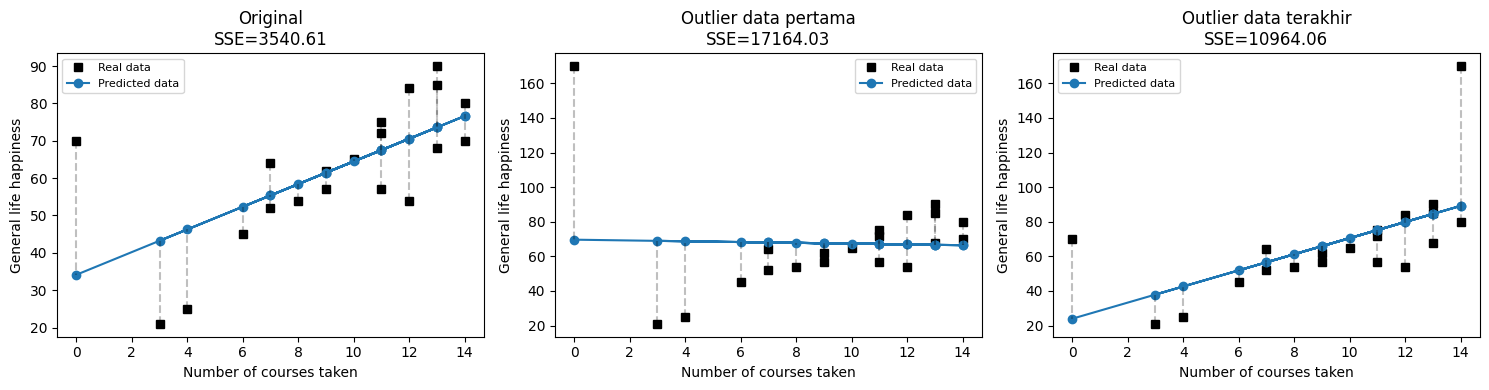

Beta original: [34.129  3.034]
Beta outlier pertama: [69.637 -0.229]
Beta outlier terakhir: [23.956  4.657]

Outlier yang sama pada y bisa memberi efek berbeda karena posisi x-nya berbeda. Ini berkaitan dengan leverage.


In [11]:
# Exercise 11-4
def fit_and_plot(ax, x, y, title):
  X_tmp = np.column_stack((np.ones(len(x)), x))
  beta_tmp = np.linalg.inv(X_tmp.T @ X_tmp) @ X_tmp.T @ y
  pred_tmp = X_tmp @ beta_tmp
  sse_tmp = np.sum((pred_tmp - y)**2)

  ax.plot(x, y, 'ks', label="Real data")
  ax.plot(x, pred_tmp, 'o-', label="Predicted data")

  for xi, yi, pi in zip(x, y, pred_tmp):
    ax.plot([xi, xi], [yi, pi], 'k--', alpha=.25)

  ax.set_title(f"{title}\nSSE={sse_tmp:.2f}")
  ax.set_xlabel("Number of courses taken")
  ax.set_ylabel("General life happiness")
  ax.legend(fontsize=8)

  return beta_tmp, sse_tmp

happiness_original = happiness.copy()

happiness_outlier_first = happiness.copy()
happiness_outlier_first[0] = 170

happiness_outlier_last = happiness.copy()
happiness_outlier_last[-1] = 170

fig, axes = plt.subplots(1, 3, figsize=(15,4))

b0, s0 = fit_and_plot(axes[0], numcourses, happiness_original, "Original")
b1, s1 = fit_and_plot(axes[1], numcourses, happiness_outlier_first, "Outlier data pertama")
b2, s2 = fit_and_plot(axes[2], numcourses, happiness_outlier_last, "Outlier data terakhir")

plt.tight_layout()
plt.show()

print("Beta original:", np.round(b0, 3))
print("Beta outlier pertama:", np.round(b1, 3))
print("Beta outlier terakhir:", np.round(b2, 3))

print("\nOutlier yang sama pada y bisa memberi efek berbeda karena posisi x-nya berbeda. Ini berkaitan dengan leverage.")

## Exercise 11-5

Hitung matrix inverse menggunakan least squares.  
Gunakan persamaan:

$$XB=Y$$

dengan $X$ adalah matrix square full-rank, $B$ adalah matrix inverse yang dicari, dan $Y$ adalah identity matrix.

Apakah column-wise LS sama dengan matrix-wise LS?
True

Apakah matrix-wise LS sama dengan np.linalg.inv?
True


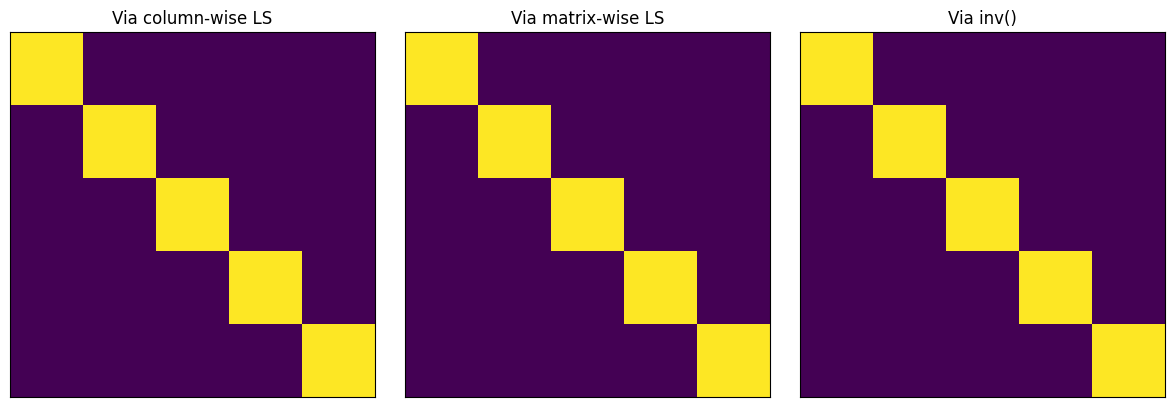

Jarak ke identity:
Via column-wise LS : 5.311760555551968e-14
Via matrix-wise LS : 5.311760555551968e-14
Via inv() : 1.7355183956615994e-15


In [12]:
# Exercise 11-5
np.random.seed(11)

N = 5
X_inv_example = np.random.randn(N, N)

while np.linalg.matrix_rank(X_inv_example) < N:
  X_inv_example = np.random.randn(N, N)

Y_identity = np.eye(N)

# Cara 1: least squares kolom per kolom
B_columnwise = np.zeros((N, N))

for i in range(N):
  yi = Y_identity[:, i]
  B_columnwise[:, i] = np.linalg.inv(X_inv_example.T @ X_inv_example) @ X_inv_example.T @ yi

# Cara 2: least squares langsung satu matrix
B_matrixwise = np.linalg.inv(X_inv_example.T @ X_inv_example) @ X_inv_example.T @ Y_identity

# Cara 3: inverse bawaan NumPy
B_inv = np.linalg.inv(X_inv_example)

print("Apakah column-wise LS sama dengan matrix-wise LS?")
print(np.allclose(B_columnwise, B_matrixwise))

print("\nApakah matrix-wise LS sama dengan np.linalg.inv?")
print(np.allclose(B_matrixwise, B_inv))

fig, axes = plt.subplots(1, 3, figsize=(12,4))

products = [
  X_inv_example @ B_columnwise,
  X_inv_example @ B_matrixwise,
  X_inv_example @ B_inv
]

titles = [
  "Via column-wise LS",
  "Via matrix-wise LS",
  "Via inv()"
]

for ax, mat, title in zip(axes, products, titles):
  ax.imshow(mat)
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

print("Jarak ke identity:")
for title, mat in zip(titles, products):
  print(title, ":", np.linalg.norm(mat - np.eye(N)))